array([1.        , 1.30103   , 1.47712125, 1.60205999, 1.69897   ,
       1.77815125, 1.84509804, 1.90308999, 1.95424251, 2.        ])

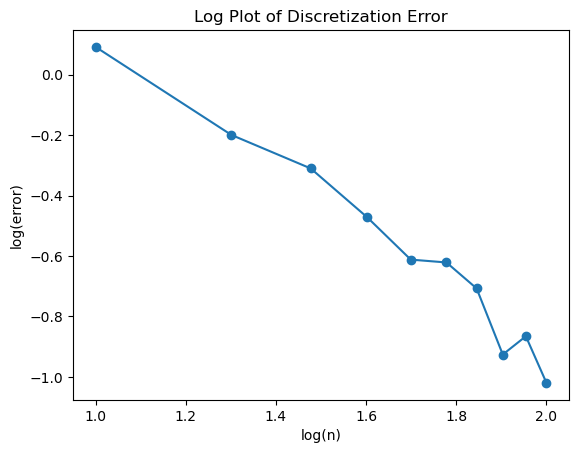

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def euler(T, n, output_index=-1):
    X = [1]
    delta_t = T / n
    for i in np.arange(1, n+1):
        X.append(X[i-1] + 2 * X[i-1] * delta_t + np.sqrt(delta_t) * rng.normal())
    return X[output_index]

def euler_sample_mean(T, n, num_samples):
    samples = []
    for i in range(num_samples):
        samples.append(euler(T, n))
    return np.mean(samples)

def discretization_error(T, num_samples):
    fn = []
    for n in np.arange(10,101,10):
        fn.append(np.abs(euler_sample_mean(T, n, num_samples) - np.exp(2)))
    return fn

discretization = discretization_error(1, 10000)
X = np.log10(np.arange(10,101,10))
Y = np.log10(discretization)

plt.plot(X, Y, marker='o')
plt.xlabel('log(n)')
plt.ylabel('log(error)')
plt.title('Log Plot of Discretization Error')